# 02 · Tracked training and evaluation

Train the release candidate through the same package entry point used by the CLI and interface. The workflow records an MLflow run, evaluates cross-validation and held-out performance, applies a quality gate, and packages the approved estimator with its metadata.

## Objectives

- Run a deterministic scikit-learn training pipeline.
- Inspect cross-validation and held-out metrics.
- Read the confusion matrix as release evidence.
- Examine the portable model bundle and exercise a failed quality gate.

In [1]:
import logging
import os
from pathlib import Path
from tempfile import TemporaryDirectory

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

import matplotlib.pyplot as plt
import pandas as pd

from mlops_demo.model import load_bundle
from mlops_demo.train import TrainingConfig, train_model

logging.getLogger("mlflow").setLevel(logging.WARNING)
plt.style.use("dark_background")
ACCENT = "#76B900"

## Define a reproducible run

A temporary workspace keeps this notebook self-contained. The seed, split, and release threshold are explicit inputs rather than hidden notebook state.

In [2]:
session = TemporaryDirectory(prefix="mlops-notebook-")
workspace = Path(session.name)
config = TrainingConfig(
    artifacts_dir=workspace / "artifacts",
    tracking_dir=workspace / "mlruns",
    experiment_name="notebook-training",
    test_size=0.20,
    random_state=42,
    accuracy_threshold=0.90,
)
pd.Series(
    {
        "test_size": config.test_size,
        "random_state": config.random_state,
        "max_iter": config.max_iter,
        "accuracy_threshold": config.accuracy_threshold,
    },
    name="value",
).to_frame()

,value
test_size,0.2
random_state,42.0
max_iter,500.0
accuracy_threshold,0.9


## Train, evaluate, gate, and package

`train_model()` owns the full release path. A successful call means the quality gate passed and the model plus evaluation summary were written as release artifacts.

In [3]:
summary = train_model(config)
metric_names = ["accuracy", "f1_macro", "cv_accuracy_mean", "cv_accuracy_std"]
metrics = pd.Series({name: summary[name] for name in metric_names}, name="value")
metrics.to_frame().style.format("{:.3f}")

,value
accuracy,0.933
f1_macro,0.933
cv_accuracy_mean,0.958
cv_accuracy_std,0.026


The held-out set is untouched during fitting. Cross-validation gives a second view of stability, while macro F1 prevents a majority class from hiding weak minority-class performance.

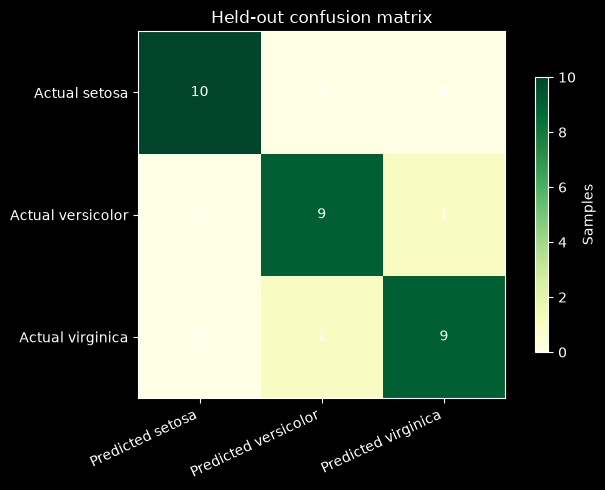

In [4]:
confusion = pd.DataFrame(
    summary["confusion_matrix"],
    index=[f"Actual {name}" for name in summary["class_names"]],
    columns=[f"Predicted {name}" for name in summary["class_names"]],
)

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(confusion, cmap="YlGn")
ax.set_xticks(range(len(confusion.columns)), confusion.columns, rotation=25, ha="right")
ax.set_yticks(range(len(confusion.index)), confusion.index)
ax.set_title("Held-out confusion matrix")
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(column, row, confusion.iloc[row, column], ha="center", va="center", color="white")
fig.colorbar(image, ax=ax, shrink=0.75, label="Samples")
plt.tight_layout()
plt.show()

## Inspect the release artifact

The bundle stores more than an estimator. It carries feature order, labels, evaluation metrics, the training baseline used for drift checks, version information, and the originating MLflow run ID.

In [5]:
bundle = load_bundle(config.artifacts_dir / "model.joblib")
pd.Series(
    {
        "model_version": bundle.model_version,
        "feature_count": len(bundle.feature_names),
        "target_classes": ", ".join(bundle.target_names),
        "quality_gate": summary["quality_gate"],
        "held_out_samples": summary["test_sample_count"],
        "run_id_prefix": bundle.run_id[:8],
    },
    name="release metadata",
).to_frame()

,release metadata
model_version,0.2.0
feature_count,4
target_classes,"setosa, versicolor, virginica"
quality_gate,passed
held_out_samples,30
run_id_prefix,6a72fd36


## Exercise the rejection path

A deliberately unrealistic threshold demonstrates that a failed candidate remains tracked but is not promoted to a release artifact.

In [6]:
strict_config = TrainingConfig(
    artifacts_dir=workspace / "rejected-artifacts",
    tracking_dir=config.tracking_dir,
    experiment_name=config.experiment_name,
    random_state=42,
    accuracy_threshold=0.99,
)

try:
    train_model(strict_config)
except RuntimeError as error:
    print(error)

print(f"Release artifact exists: {(strict_config.artifacts_dir / 'model.joblib').exists()}")

Quality gate failed: accuracy 0.933 is below 0.990
Release artifact exists: False


## Takeaways

- One function provides the same deterministic release behavior to the CLI, UI, tests, and notebook.
- Cross-validation and held-out metrics both support the release decision.
- The packaged model remains traceable to its data contract and MLflow run.
- A failed quality gate records evidence without producing a promoted artifact.